In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
df = pd.read_csv("processed/state_year_panel.csv")
df.head()

,state,year,fatalities,fatalities_under21,fatalities_over21,fatalities_age_unknown,motorcycles,fatality_rate_per_10k_reg,population,fatality_rate_per_100k_pop,treated,repeal_year,event_time,post,exemption_age,reg_data_quality_flag
0,Alabama,1995,33,4,29,0,37445,8.812926,4262731,0.774152,0,NaN,NaN,0,NaN,ok
1,Alabama,1996,31,3,28,0,36225,8.557626,4290403,0.722543,0,NaN,NaN,0,NaN,ok
2,Alabama,1997,29,4,25,0,38544,7.523869,4320281,0.671253,0,NaN,NaN,0,NaN,ok
3,Alabama,1998,34,8,26,0,44058,7.717100,4351037,0.781423,0,NaN,NaN,0,NaN,ok
4,Alabama,1999,32,5,27,0,48715,6.568819,4369862,0.732289,0,NaN,NaN,0,NaN,ok


In [3]:
print(df.columns.tolist())

treated_states = (
    df.loc[df["treated"] == 1, ["state", "repeal_year"]]
      .drop_duplicates()
      .sort_values("repeal_year")
)

treated_states

['state', 'year', 'fatalities', 'fatalities_under21', 'fatalities_over21', 'fatalities_age_unknown', 'motorcycles', 'fatality_rate_per_10k_reg', 'population', 'fatality_rate_per_100k_pop', 'treated', 'repeal_year', 'event_time', 'post', 'exemption_age', 'reg_data_quality_flag']


,state,repeal_year
84,Arkansas,1997.0
1204,Texas,1997.0
476,Kentucky,1998.0
252,Florida,2000.0
1064,Pennsylvania,2003.0
616,Michigan,2012.0
700,Missouri,2020.0


In [4]:
plot_df = (
    df.loc[df["treated"] == 1, [
        "state",
        "year",
        "repeal_year",
        "event_time",
        "fatality_rate_per_10k_reg"
    ]]
    .dropna(subset=["event_time", "fatality_rate_per_10k_reg"])
    .sort_values(["state", "event_time"])
    .copy()
)

plot_df["event_time"] = plot_df["event_time"].astype(int)

plot_df.head()

,state,year,repeal_year,event_time,fatality_rate_per_10k_reg
84,Arkansas,1995,1997.0,-2,9.886595
85,Arkansas,1996,1997.0,-1,15.178192
86,Arkansas,1997,1997.0,0,13.276501
87,Arkansas,1998,1997.0,1,13.301031
88,Arkansas,1999,1997.0,2,10.107043


In [5]:
plot_df.groupby("state")["event_time"].agg(["min", "max", "count"])

,min,max,count
state,,,
Arkansas,-2,25,28
Florida,-5,22,28
Kentucky,-3,24,28
Michigan,-17,10,28
Missouri,-25,2,28
Pennsylvania,-8,19,28
Texas,-2,25,28


In [6]:
WINDOW_LEFT = -6
WINDOW_RIGHT = 10

plot_df = plot_df[
    (plot_df["event_time"] >= WINDOW_LEFT) &
    (plot_df["event_time"] <= WINDOW_RIGHT)
].copy()

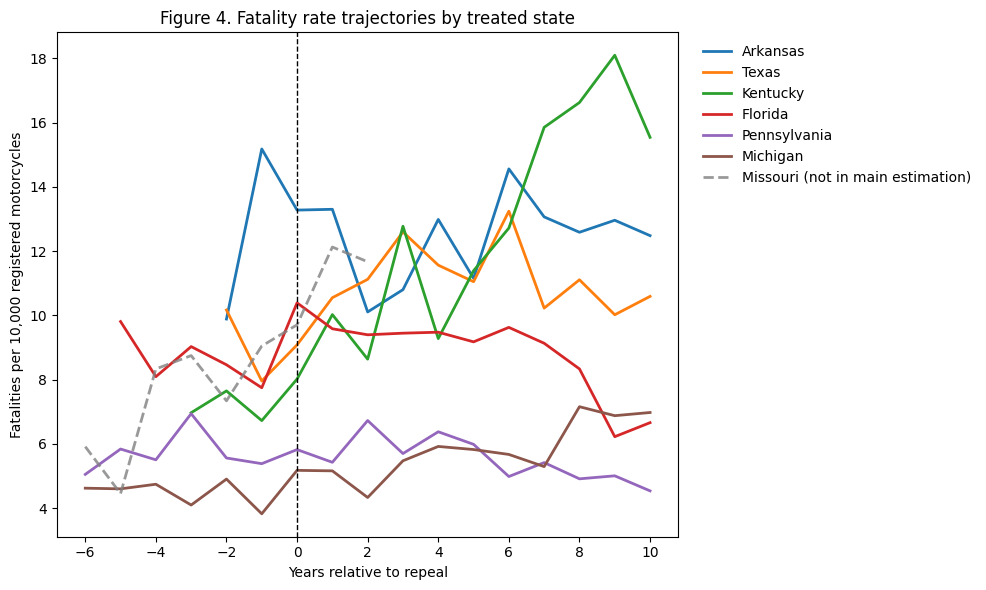

In [10]:
plt.figure(figsize=(10, 6))

state_order = ["Arkansas", "Texas", "Kentucky", "Florida", "Pennsylvania", "Michigan", "Missouri"]

for state in state_order:
    g = plot_df.loc[plot_df["state"] == state].sort_values("event_time")
    if state == "Missouri":
        plt.plot(
            g["event_time"],
            g["fatality_rate_per_10k_reg"],
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            color="gray",
            label=f"{state} (not in main estimation)"
        )
    else:
        plt.plot(
            g["event_time"],
            g["fatality_rate_per_10k_reg"],
            linewidth=2,
            label=state
        )

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Years relative to repeal")
plt.ylabel("Fatalities per 10,000 registered motorcycles")
plt.title("Figure 4. Fatality rate trajectories by treated state")
plt.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()